In [6]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
import glob
import os,sys
import fitsio as fio
from tqdm import tqdm
import proplot as pplt
import pickle
import glob
from astropy.io import fits
from scipy.optimize import curve_fit
import healsparse
import healpy as hp
import pandas as pd
from math import log10
import healsparse as hsp
import skyproj
from des_y6utils import mdet
import h5py as h5
import healpy as hp
import healsparse as hsp


%matplotlib inline
matplotlib.rcParams.update({'font.size': 16})

# nside_sparse = 1024
nside_sparse = 4096

In [7]:
def read_mdet_h5(datafile, gal_weight_file, keys, mdet_step, patch_id=None, response=False, subtract_mean_shear=False, ):

    def assign_loggrid(x, y, xmin, xmax, xsteps, ymin, ymax, ysteps):
        """
        Computes indices of 2D grids. Only used when we use shear weight that is binned by S/N and size ratio. 
        """
        from math import log10
        # return x and y indices of data (x,y) on a log-spaced grid that runs from [xy]min to [xy]max in [xy]steps

        logstepx = log10(xmax/xmin)/xsteps
        logstepy = log10(ymax/ymin)/ysteps

        indexx = (np.log10(x/xmin)/logstepx).astype(int)
        indexy = (np.log10(y/ymin)/logstepy).astype(int)

        indexx = np.maximum(indexx,0)
        indexx = np.minimum(indexx, xsteps-1)
        indexy = np.maximum(indexy,0)
        indexy = np.minimum(indexy, ysteps-1)

        return indexx,indexy

    def _find_shear_weight(dat, mask, wgt_dict, snmin, snmax, sizemin, sizemax, steps, mdet_mom):

        """
        Assigns shear weights to the objects based on the grids. 
        """
        
        if wgt_dict is None:
            weights = np.ones(len(dat))
            return weights

        shear_wgt = wgt_dict['weight']
        smoothing = True
        if smoothing:
            from scipy.ndimage import gaussian_filter
            smooth_response = gaussian_filter(wgt_dict['response'], sigma=2.0)
            shear_wgt = (smooth_response/wgt_dict['meanes'])**2
        indexx, indexy = assign_loggrid(np.array(dat[mdet_mom+'_s2n'])[mask], np.array(dat[mdet_mom+'_T_ratio'])[mask], snmin, snmax, steps, sizemin, sizemax, steps)
        weights = np.array([shear_wgt[x, y] for x, y in zip(indexx, indexy)])
        
        return weights

    def _get_shear_weights(dat, mask, gal_weight_file, shape_err=False):
        if shape_err:
            return 1/(0.22**2 + 0.5*(np.array(dat['gauss_g_cov_1_1'])[mask] + np.array(dat['gauss_g_cov_2_2'])[mask]))
        else:
            with open(gal_weight_file, 'rb') as handle:
                wgt_dict = pickle.load(handle)
                snmin = wgt_dict['xedges'][0]
                snmax = wgt_dict['xedges'][-1]
                sizemin = wgt_dict['yedges'][0]
                sizemax = wgt_dict['yedges'][-1]
                steps = len(wgt_dict['xedges'])-1
            shear_wgt = _find_shear_weight(dat, mask, wgt_dict, snmin, snmax, sizemin, sizemax, steps, 'gauss')
            return shear_wgt

    def _wmean(q,w):
        return np.sum(q*w)/np.sum(w)
    
    import h5py as h5
    f = h5.File(datafile, 'r')
    d = f.get('/mdet/'+mdet_step)
    if patch_id is None:
        nrows = len(np.array( d['ra'] ))
        mask = np.ones(nrows)!=0
    else:
        mask = (np.array( d['patch_num'] ) == patch_id)
        nrows = len(np.array( d['ra'] )[mask])
    formats = []
    for key in keys:
        formats.append('f4')
    data = np.recarray(shape=(nrows,), formats=formats, names=keys)
    for key in keys:  
        if key == 'R':
            continue
        elif key == 'w':
            data['w'] = _get_shear_weights(d, mask, gal_weight_file)
        elif key in ('g1', 'g2'):
            data[key] = np.array(d['gauss_'+key[0]+'_'+key[1]])[mask]
        elif key == 'gauss_T':
            data[key] = np.array(d['gauss_psf_T'])[mask] * np.array(d['gauss_T_ratio'])[mask]
        elif key == 'gmi':
            mag_g = mdet._compute_asinh_mags(np.array(d["pgauss_band_flux_g"])[mask], 0)
            mag_i = mdet._compute_asinh_mags(np.array(d["pgauss_band_flux_i"])[mask], 2)
            data[key] = mag_g - mag_i
        else:
            data[key] = np.array(d[key])[mask]
    print('made recarray with hdf5 file')
    
    # response correction
    if response:
        d_2p = f.get('/mdet/2p'); nrows = len(np.array( d_2p['ra'] )); mask_2p = np.ones(nrows)!=0
        d_1p = f.get('/mdet/1p'); nrows = len(np.array( d_1p['ra'] )); mask_1p = np.ones(nrows)!=0
        d_2m = f.get('/mdet/2m'); nrows = len(np.array( d_2m['ra'] )); mask_2m = np.ones(nrows)!=0
        d_1m = f.get('/mdet/1m'); nrows = len(np.array( d_1m['ra'] )); mask_1m = np.ones(nrows)!=0
        # compute response with weights
        g1p = _wmean(np.array(d_1p["gauss_g_1"]), _get_shear_weights(d_1p, mask_1p, gal_weight_file))                                     
        g1m = _wmean(np.array(d_1m["gauss_g_1"]), _get_shear_weights(d_1m, mask_1m, gal_weight_file))
        R11 = (g1p - g1m) / 0.02

        g2p = _wmean(np.array(d_2p["gauss_g_2"]), _get_shear_weights(d_2p, mask_2p, gal_weight_file))
        g2m = _wmean(np.array(d_2m["gauss_g_2"]), _get_shear_weights(d_2m, mask_2m, gal_weight_file))
        R22 = (g2p - g2m) / 0.02

        R = (R11 + R22)/2.
        # data['g1'] /= R
        # data['g2'] /= R
        data['R'] = np.ones(len(data['g1'])) * R

        mean_g1 = _wmean(data['g1'], data['w'])
        mean_g2 = _wmean(data['g2'], data['w'])
        # mean shear subtraction
        if subtract_mean_shear:
            print('subtracting mean shear')
            print('mean g1 g2 =(%1.8f,%1.8f)'%(mean_g1, mean_g2))          
            data['g1'] -= mean_g1
            data['g2'] -= mean_g2

    return data

In [2]:
def make_maps(q, ra, dec, nside, count=False):
    
    map_array = np.zeros(hp.nside2npix(nside))
    pix = hp.pixelfunc.ang2pix(nside, ra, dec, lonlat=True, nest=True)
    # theta = (90.0 - dec) * np.pi / 180.
    # phi = ra * np.pi / 180.
    # pix = hp.pixelfunc.ang2pix(nside, ra, dec, nest=False)
    unique_pix, idx, idx_rep = np.unique(pix, return_index=True, return_inverse=True)
    if count:
        map_array[unique_pix] += np.bincount(idx_rep, weights=np.ones(len(pix)))
    else:
        map_array[unique_pix] += np.bincount(idx_rep, weights=q)
    
    return map_array

def gen_annot_text_quartile(dat, imname):
    
    a = np.percentile(dat,75) - np.percentile(dat,25)
    text = r"$IQR_{%s}$ = " % imname
    text += "{:.3f}".format(a)
    
    return text

0.11336757965740557 0.12824965219334214 0.12883221401362047 0.11035800040937105


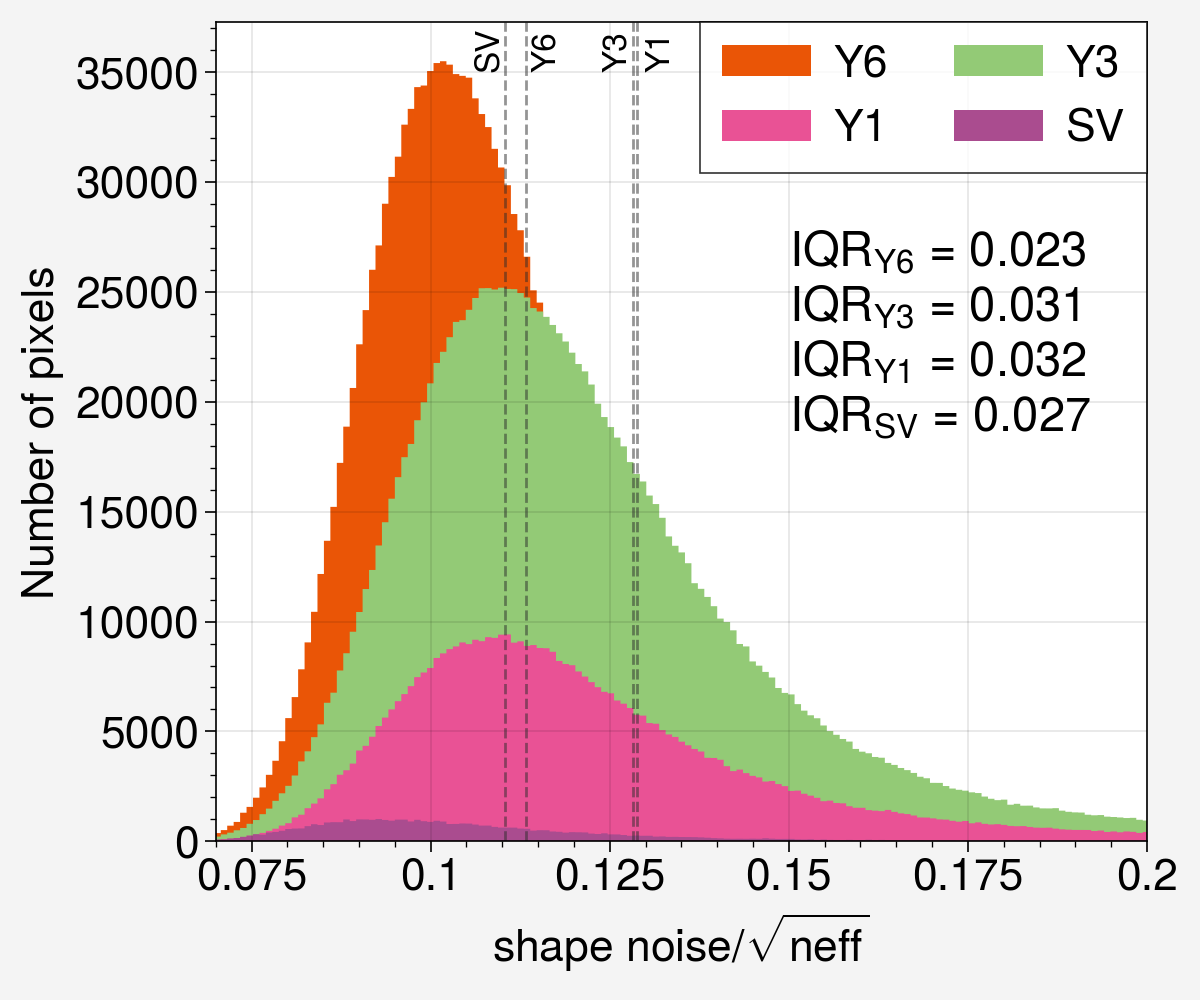

In [53]:
matplotlib.rcParams.update({'font.size': 16})

v = dict()
for f in ['sv', 'y1', 'y3', 'y6']:
    with open('/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/'+f+'_maps.pkl', 'rb') as n:
        d = pickle.load(n)
    v[f] = d
releases = ['SV', 'Y1', 'Y3', 'Y6']
colors = ['#aa4c8f', '#e95295', '#93ca76', '#ea5506']

y6 = v['y6']['neff'][v['y6']['mask']] / v['y6']['sige'][v['y6']['mask']]**2
y6_ = v['y6']['sige'][v['y6']['mask']] / np.sqrt(v['y6']['neff'][v['y6']['mask']])
iqr_y6 = gen_annot_text_quartile(y6, 'Y6'); iqr_y6_ = gen_annot_text_quartile(y6_, 'Y6')
y3 = v['y3']['neff'][v['y3']['mask']] / v['y3']['sige'][v['y3']['mask']]**2
y3_ = v['y3']['sige'][v['y3']['mask']] / np.sqrt(v['y3']['neff'][v['y3']['mask']])
iqr_y3 = gen_annot_text_quartile(y3, 'Y3'); iqr_y3_ = gen_annot_text_quartile(y3_, 'Y3')
y1 = v['y1']['neff'][v['y1']['mask']] / v['y1']['sige'][v['y1']['mask']]**2
y1_ = v['y1']['sige'][v['y1']['mask']] / np.sqrt(v['y1']['neff'][v['y1']['mask']])
iqr_y1 = gen_annot_text_quartile(y1, 'Y1'); iqr_y1_ = gen_annot_text_quartile(y1_, 'Y1')
sv = v['sv']['neff'][v['sv']['mask']] / v['sv']['sige'][v['sv']['mask']]**2
sv_ = v['sv']['sige'][v['sv']['mask']] / np.sqrt(v['sv']['neff'][v['sv']['mask']])
iqr_sv = gen_annot_text_quartile(sv, 'SV'); iqr_sv_ = gen_annot_text_quartile(sv_, 'SV')

# values, bins, _ = ax.hist((y6,y3,y1,sv), bins=500, range=(0.01, 200), stacked=True)
# area = sum(np.diff(bins)*values)
# plt.clf()
# hist, bin_edges = np.histogram(y6, bins=500, range=(0.01, 200))
# _=ax.hist(hist/area, bins=bins, c=colors[3], histtype='step', label=releases[3])
# hist, bin_edges = np.histogram(y3, bins=500, range=(0.01, 200))
# _=ax.hist(hist/area, bins=bins, c=colors[2], histtype='step', label=releases[2])
# hist, bin_edges = np.histogram(y1, bins=500, range=(0.01, 200))
# _=ax.hist(hist/area, bins=bins, c=colors[1], histtype='step', label=releases[1])
# hist, bin_edges = np.histogram(sv, bins=500, range=(0.01, 200))
# _=ax.hist(hist/area, bins=bins, c=colors[0], histtype='step', label=releases[0])


fig,ax = pplt.subplots(figsize=(6,5))
bins = 50
# _=ax.hist(y6, bins=500, range=(0.01, 200), c=colors[3], histtype='stepfilled', label=releases[3])
# ax.axvline(np.mean(y6), color='#2b2b2b', linestyle = 'dashed', alpha=0.5, linewidth = 1)
# _=ax.hist(y3, bins=500, range=(0.01, 200), c=colors[2], histtype='stepfilled', label=releases[2])
# ax.axvline(np.mean(y3), color='#2b2b2b', linestyle = 'dashed', alpha=0.5, linewidth = 1)
# _=ax.hist(y1, bins=500, range=(0.01, 200), c=colors[1], histtype='stepfilled', label=releases[1])
# ax.axvline(np.mean(y1), color='#2b2b2b', linestyle = 'dashed', alpha=0.5, linewidth = 1)
# _=ax.hist(sv, bins=500, range=(0.01, 200), c=colors[0], histtype='stepfilled', label=releases[0])
# ax.axvline(np.mean(sv), color='#2b2b2b', linestyle = 'dashed', alpha=0.5, linewidth = 1)
# ax.text(130, 6400, iqr_y6+'\n'+iqr_y3+'\n'+iqr_y1+'\n'+iqr_sv, ha="left", va="center", size=17,)
# ax.set_xlim(0, 200)


_=ax.hist(y6_, bins=500, range=(0.05, 0.5), c=colors[3], histtype='stepfilled', label=releases[3])
ax.axvline(np.mean(y6_), color='#2b2b2b', linestyle = 'dashed', alpha=0.5, linewidth = 1)
_=ax.hist(y3_, bins=500, range=(0.05, 0.5), c=colors[2], histtype='stepfilled', label=releases[2])
ax.axvline(np.mean(y3_), color='#2b2b2b', linestyle = 'dashed', alpha=0.5, linewidth = 1)
_=ax.hist(y1_, bins=500, range=(0.05, 0.5), c=colors[1], histtype='stepfilled', label=releases[1])
ax.axvline(np.mean(y1_), color='#2b2b2b', linestyle = 'dashed', alpha=0.5, linewidth = 1)
_=ax.hist(sv_, bins=500, range=(0.05, 0.5), c=colors[0], histtype='stepfilled', label=releases[0])
ax.axvline(np.mean(sv_), color='#2b2b2b', linestyle = 'dashed', alpha=0.5, linewidth = 1)
print(np.mean(y6_), np.mean(y3_), np.mean(y1_), np.mean(sv_))

ax.text(0.15, 23000, iqr_y6_+'\n'+iqr_y3_+'\n'+iqr_y1_+'\n'+iqr_sv_, ha="left", va="center", size=17,)
ax.text(0.114, 35000, 'Y6', rotation=90, ha='left', va='bottom', size=12)
ax.text(0.124, 35000, 'Y3', rotation=90, ha='left', va='bottom', size=12)
ax.text(0.130, 35000, 'Y1', rotation=90, ha='left', va='bottom', size=12)
ax.text(0.106, 35000, 'SV', rotation=90, ha='left', va='bottom', size=12)
ax.set_xlim(0.07, 0.2)
# ax.set_xlabel(r'neff/shape noise$^2$')
ax.set_xlabel(r'shape noise/$\sqrt{\rm neff}$')
ax.set_ylabel('Number of pixels')
ax.legend(loc='upper right', ncol=2)

plt.savefig('/global/homes/m/myamamot/DES/des-y6-analysis/vf_figures/v6_UNBLINDED/neff_sige_sv2y6_flip.pdf', bbox_inches='tight')

# New version (11/9/24)

In [8]:
nside_sparse = 1024
pixarea = hp.nside2pixarea(nside_sparse,degrees=True) * 3600.
dd = [{'name':s} for s in ('sv','y1','y3','y6')]
for i, c in enumerate(['#fcc800','#e2041b','#38b48b','#65318e']):
    dd[i]['color']=c
m = [0.05, 0.025, 0.02, 0.0035]
for i,d in enumerate(dd):

    p = pickle.load(open('/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/{:s}_maps.pkl'.format(d['name']),'rb'))
    tmp = p['neff'] / p['sige']**2
    bias = 1/(m[i]**2 + 1/tmp)
    good = np.logical_and(p['mask'],p['neff']>0)
    d['info'] = tmp[good]
    d['info_bias'] = bias[good]
    d['area'] = pixarea * len(d['info']) / 3600.  # Survey area in sq deg
    d['total'] = np.sum(d['info'])*pixarea  # Total shear information
    d['median'] = np.median(d['info']) 
    d['median_bias'] = np.median(d['info_bias']) 
    d['iq'] = np.diff(np.percentile(d['info'],(25.,75)))
    d['iq_bias'] = np.diff(np.percentile(d['info_bias'],(25.,75))) 
    print(d['name'],d['area'],d['total'],d['median'],np.median(p['sige'][good]), d['iq'], d['iq_bias'])
dd[0]['area'] = 139.
dd[1]['area'] = 1500.
dd[2]['area'] = 4143.
dd[3]['area'] = 4422.

sv 156.33483387458784 44815803.14146055 78.88849217818684 0.2768192924288424 [38.2184969] [26.66432418]
y1 1749.5010464610739 465656706.1237974 72.86461014297376 0.27574134918199433 [38.56932722] [35.26755215]
y3 4759.614591047717 1266230714.0777838 72.29752439258905 0.2603206216299291 [37.54741531] [35.44643076]
y6 5016.179445709007 1601947714.3170624 87.79025081161993 0.2886426449827934 [36.80602162] [36.72651995]


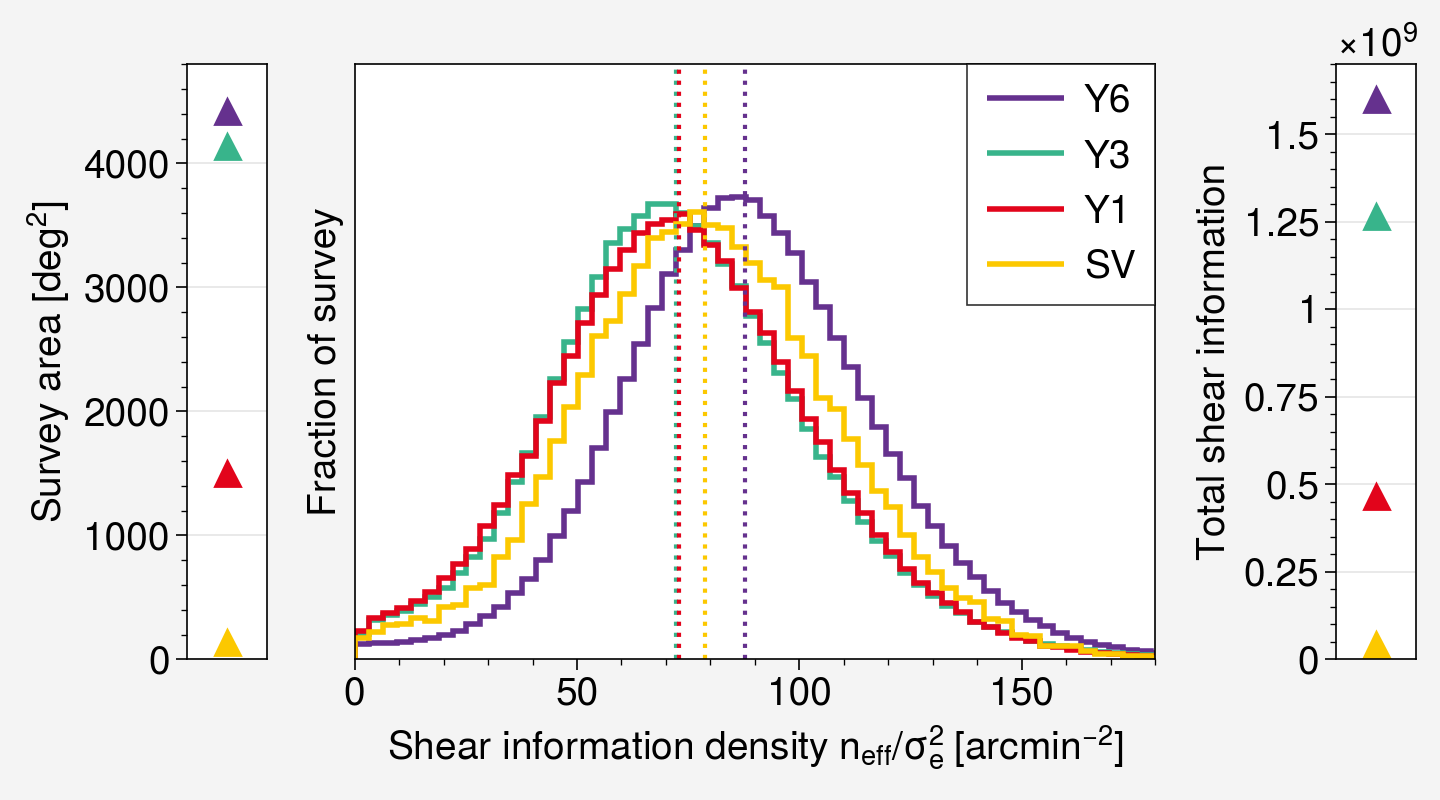

In [16]:
matplotlib.rcParams.update({'font.size': 14, 'lines.markersize':9})
fig,ax = pplt.subplots(nrows=1,ncols=3, width_ratios=(0.5,5,0.5), figsize=(7.2,4), sharex=False, sharey=False)
for d in dd[::-1]:
    cts,bins = np.histogram(d['info'], bins=70, range=(0,220))
    # cts,bins = np.histogram(d['info_bias'], bins=100, range=(0,200))
    cts = cts/np.sum(cts)
    ax[1].stairs(cts,bins,color=d['color'], label=d['name'].upper(), lw=2)
    ax[1].axvline(d['median'],ls=':',color=d['color'])
    ax[0].plot(0,d['area'],marker='^',color=d['color'])
    ax[2].plot(0,d['total'],marker='^',color=d['color'])

ax[1].set_xlim(0,180)
ax[1].set_ylim(0,0.06)
# ax[2].set_ylim(0,0.36)
ax[1].legend(loc=0, ncol=1)
ax[1].yaxis.set_ticks([])
# ax[2].xaxis.set_ticks([0,50,100,150,200])
ax[1].grid(False)
ax[1].set_xlabel(r'Shear information density $n_{\rm eff}/\sigma^2_e\; [arcmin^{-2}]$')
# ax[2].set_xlabel(r'Shear information density $1/(m^2 + \sigma^2_e/n_{\rm eff})\; [arcmin^{-2}]$')
ax[1].set_ylabel('Fraction of survey')

ax[0].set_ylim(0,4800)
ax[0].set_ylabel('Survey area [deg$^{2}$]')
ax[0].xaxis.set_ticks([])

ax[2].set_ylim(0,1.7e9)
ax[2].set_ylabel('Total shear information')
ax[2].xaxis.set_ticks([])
plt.savefig('/global/homes/m/myamamot/DES/des-y6-analysis/vf_figures/v6_UNBLINDED/shear_information_sv2y6.pdf', bbox_inches='tight')

In [2]:
m1_sv = -0.030; sigmam1_sv = 0.0015; m2_sv = -0.035; sigmam2_sv = 0.0015
m_y1 = 0.012; sigmam_y1 = 0.013
m1_y3 = -0.0223; sigmam1_y3 = 0.0016; m2_y3 = -0.0193; sigmam2_y3 = 0.0017
m1_y6 = 0.0034; sigmam1_y6 = 0.0033

Text(0, 0.5, 'multiplicative bias, m')

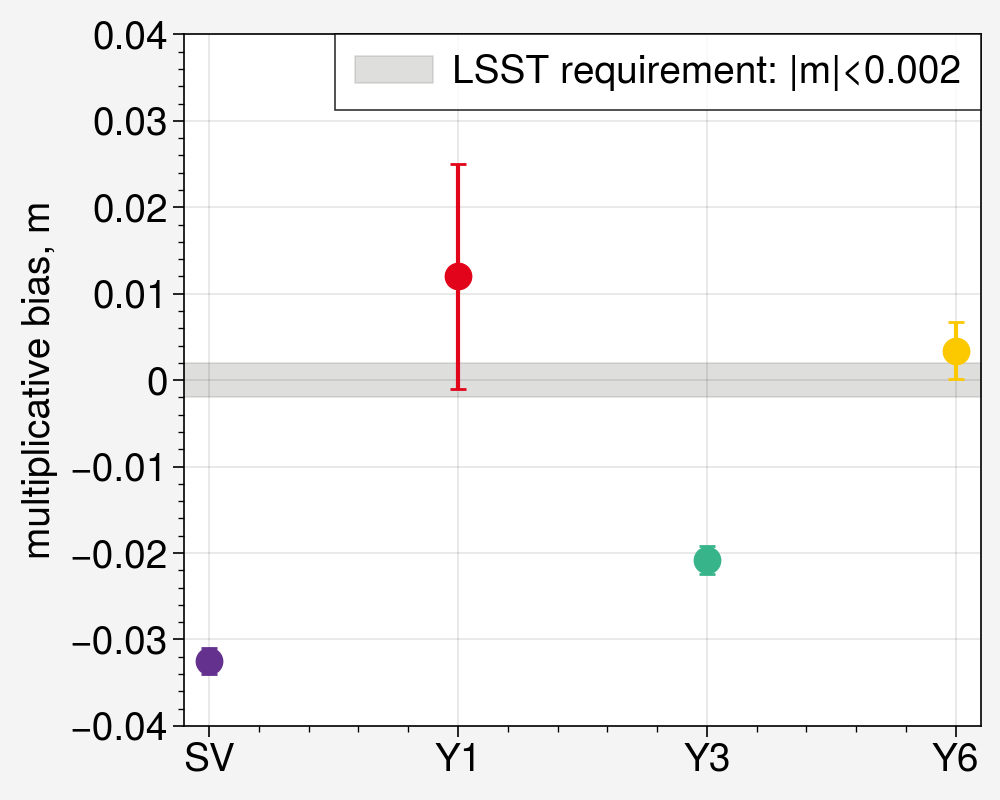

In [12]:
matplotlib.rcParams.update({'font.size': 14, 'lines.markersize':9})
fig,ax = pplt.subplots(figsize=(5,4), sharex=False, sharey=False)
cs = (['#65318e','#e2041b','#38b48b','#fcc800'])

# LSST requirement
ax.fill_between([-0.1,3.1], -0.002, +0.002, c='grey', alpha=0.3, label='LSST requirement: |m|<0.002')
ax.legend()

ax.errorbar(0, (m1_sv+m2_sv)/2., yerr=(sigmam1_sv+sigmam2_sv)/2., c=cs[0], fmt='o-', label='SV')
ax.errorbar(1, m_y1, yerr=sigmam_y1, c=cs[1], fmt='o-', label='Y1')
ax.errorbar(2, (m1_y3+m2_y3)/2., yerr=(sigmam1_y3+sigmam2_y3)/2., c=cs[2], fmt='o-', label='Y3')
ax.errorbar(3, m1_y6, yerr=sigmam1_y6, c=cs[3], fmt='o-', label='Y6')
# ax.set_yscale('symlog', linthresh=0.015)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['SV', 'Y1', 'Y3', 'Y6'])
# ax.set_yscale('symlog')
ax.set_xlim(-0.1, 3.1)
ax.set_ylim(-0.04, 0.04)
ax.set_ylabel('multiplicative bias, m')

# Y6

In [4]:
inpath = "/global/cfs/cdirs/des/y6-shear-catalogs"
infile = "Y6A2_METADETECT_V6_UNBLINDED/metadetect_cutsv6_all.h5"
mdet_file = os.path.join(inpath, infile)
f = h5.File(mdet_file, 'r')
keys = ['ra', 'dec', 'g1', 'g2', 'w', 'R']#, 'gauss_s2n', 'gauss_T_ratio']
wgt_file = '/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/inverse_variance_weight_v6.pickle'
d_flat = read_mdet_h5(mdet_file, wgt_file, keys, 'noshear', response=True, subtract_mean_shear=False)

made recarray with hdf5 file


In [5]:
desy6_count = make_maps(1, d_flat['ra'], d_flat['dec'], nside_sparse, count=True)
desy6_map_w = make_maps(d_flat['w'], d_flat['ra'], d_flat['dec'], nside_sparse)
desy6_map_w2 = make_maps(d_flat['w']**2, d_flat['ra'], d_flat['dec'], nside_sparse)
neff_y6 = desy6_map_w**2/desy6_map_w2/(hp.pixelfunc.nside2pixarea(nside_sparse,degrees=True)*(60*60))
hsp_map_neff_y6 = hsp.HealSparseMap(nside_coverage=nside_sparse, healpix_map=neff_y6)

# shape noise
# hsp_map_sige = hsp.HealSparseMap.read('/global/homes/m/myamamot/DES/des-y6-analysis/vf_figures/v6_UNBLINDED/shape_noise_map_nside128.fits')
e1_y6 = d_flat['g1'] - np.average(d_flat['g1'], weights=d_flat['w'])
e2_y6 = d_flat['g2'] - np.average(d_flat['g2'], weights=d_flat['w'])
sum_we2_2 = make_maps((d_flat['w']*e2_y6)**2, d_flat['ra'], d_flat['dec'], nside_sparse)
sum_we2_1 = make_maps((d_flat['w']*e1_y6)**2, d_flat['ra'], d_flat['dec'], nside_sparse)
sum_w2 = desy6_map_w2
sum_w = desy6_map_w
sum_ws = make_maps(d_flat['w']*d_flat['R'], d_flat['ra'], d_flat['dec'], nside_sparse)

sig_e_y6 = np.sqrt((sum_we2_1/sum_ws**2+sum_we2_2/sum_ws**2)*(sum_w**2/sum_w2)/2.)
hsp_map_sige_y6 = hsp.HealSparseMap(nside_coverage=nside_sparse, healpix_map=sig_e_y6)

# save
dict_maps = dict()
msk = desy6_count!=0.
dict_maps['count'] = desy6_count
dict_maps['Neff'] = desy6_map_w**2/desy6_map_w2
dict_maps['neff'] = neff_y6
dict_maps['sige'] = sig_e_y6
dict_maps['mask'] = msk
with open('/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/y6_maps.pkl', 'wb') as f:
    pickle.dump(dict_maps, f)

del d_flat

<ipython-input-5-e85681b87bab>:4: RuntimeWarning: invalid value encountered in true_divide
  neff_y6 = desy6_map_w**2/desy6_map_w2/(hp.pixelfunc.nside2pixarea(nside_sparse,degrees=True)*(60*60))
<ipython-input-5-e85681b87bab>:17: RuntimeWarning: invalid value encountered in true_divide
  sig_e_y6 = np.sqrt((sum_we2_1/sum_ws**2+sum_we2_2/sum_ws**2)*(sum_w**2/sum_w2)/2.)
<ipython-input-5-e85681b87bab>:24: RuntimeWarning: invalid value encountered in true_divide
  dict_maps['Neff'] = desy6_map_w**2/desy6_map_w2


Text(0.5, 1.08, 'shape noise (H12)')

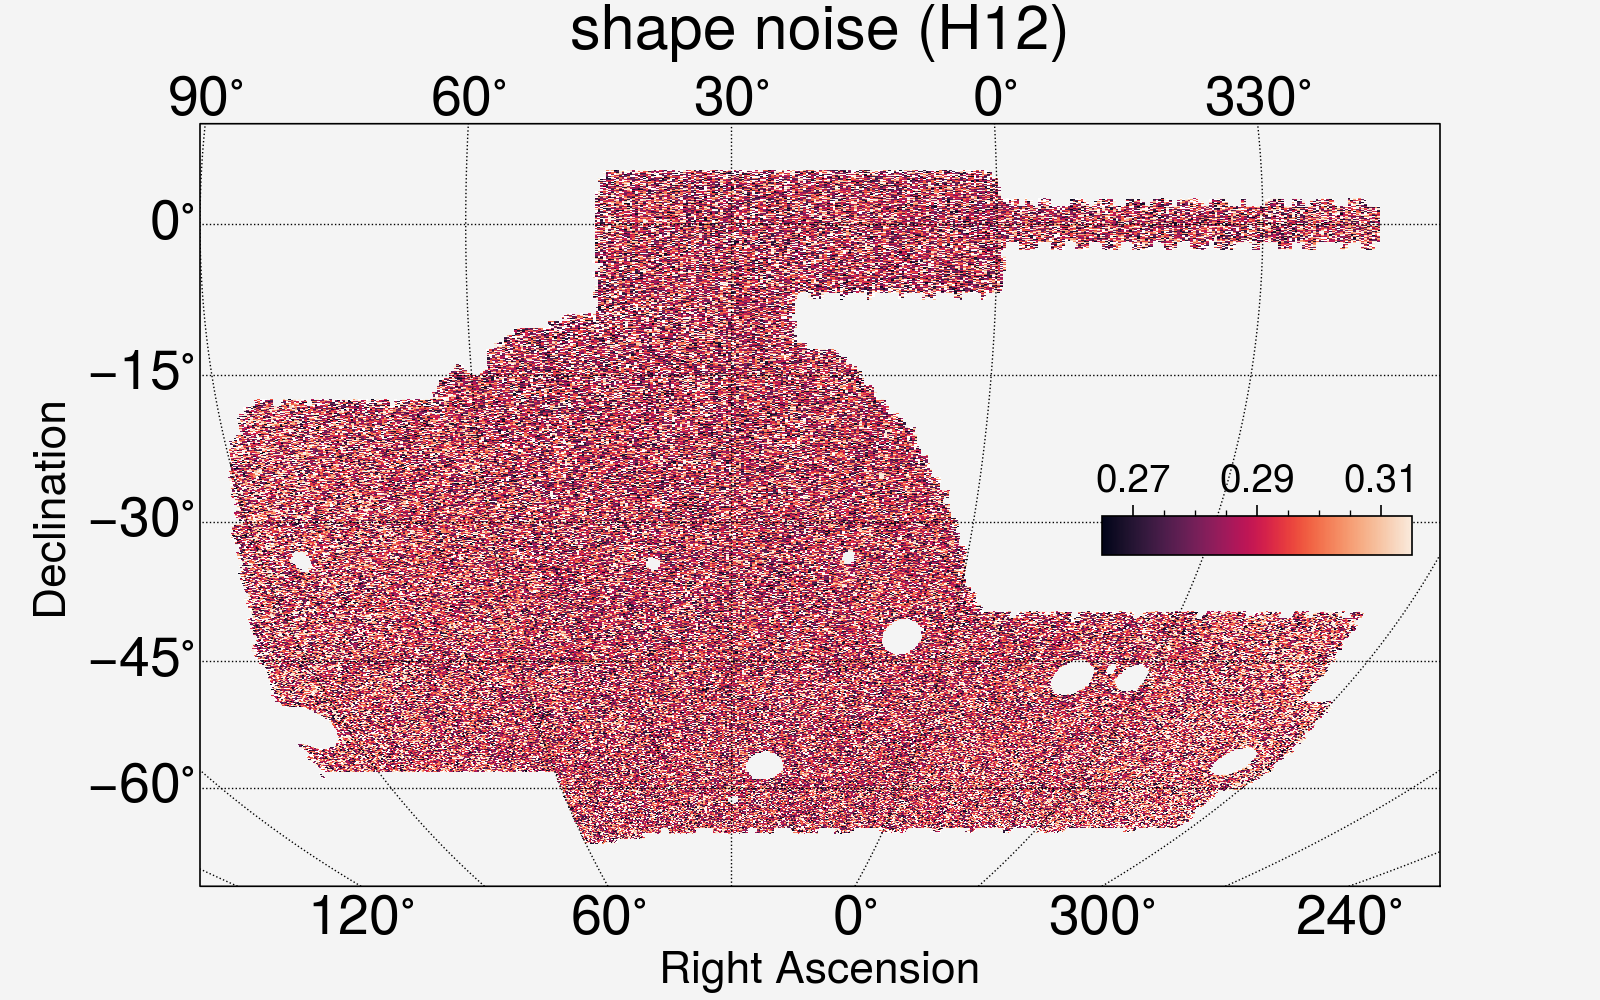

In [11]:
fig,ax = plt.subplots(figsize=(8,5))
my_cmap = matplotlib.cm.get_cmap('rocket')
my_cmap.set_under('white')
m = skyproj.DESSkyproj(ax=ax)
m.draw_des(label='DES', edgecolor='none')
_ = m.draw_hspmap(hsp_map_sige_y6, cmap=my_cmap, vmin=0.26, vmax=0.32, zoom=False)
m.draw_inset_colorbar(format='%.2f', fontsize=14)
plt.title('shape noise (H12)', y=1.08)
# plt.savefig('/global/homes/m/myamamot/DES/des-y6-analysis/vf_figures/v6_UNBLINDED/shape_noise_nside1024.pdf', bbox_inches='tight', dpi=150)

# Y3

In [3]:

#load catalog
path = '/global/cfs/cdirs/des/www/y3_cats/Y3_mastercat___UNBLIND___final_v1.1_12_22_20.h5'
m = h5.File(path,'r')
# load mask
mask = np.array(m.get('/index/select'))

# Load ra, dec
ra = np.array(m.get('/catalog/metacal/unsheared/ra'))[mask]
dec = np.array(m.get('/catalog/metacal/unsheared/dec'))[mask]


# Load weights
w = np.array(m.get('/catalog/metacal/unsheared/weight'))
w_1p = np.array(m.get('/catalog/metacal/sheared_1p/weight'))
w_2p = np.array(m.get('/catalog/metacal/sheared_2p/weight'))
w_1m = np.array(m.get('/catalog/metacal/sheared_1m/weight'))
w_2m = np.array(m.get('/catalog/metacal/sheared_2m/weight'))

# load sheared ellipticities
e1_1m = np.array(m.get('/catalog/metacal/sheared_1m/e_1'))
e1_1p = np.array(m.get('/catalog/metacal/sheared_1p/e_1'))
e2_2m = np.array(m.get('/catalog/metacal/sheared_2m/e_2'))
e2_2p = np.array(m.get('/catalog/metacal/sheared_2p/e_2'))

# compute responses
dg = 0.01
m1   = (np.average(e1_1p[mask],weights = w_1p[mask]) - np.average(e1_1m[mask],weights = w_1m[mask])) / (2.*dg)
m2   = (np.average(e2_2p[mask],weights = w_2p[mask]) - np.average(e2_2m[mask],weights = w_2m[mask])) / (2.*dg)

print ('rg',m1,m2)
del e1_1m, e1_1p, e2_2m, e2_2p, w_1p, w_1m, w_2p, w_2m

# compute selection responses
# load sheared masks
mask_1m = np.array(m['index']['select_1m'])
mask_1p = np.array(m['index']['select_1p'])
mask_2m = np.array(m['index']['select_2m'])
mask_2p = np.array(m['index']['select_2p'])

# Load ellipticities
e1 = np.array(m.get('/catalog/metacal/unsheared/e_1'))
e2 = np.array(m.get('/catalog/metacal/unsheared/e_2'))

d_m1   = (np.average(e1[mask_1p],weights = w[mask_1p]) - np.average(e1[mask_1m],weights = w[mask_1m])) / (2.*dg)
d_m2   = (np.average(e2[mask_2p],weights = w[mask_2p]) - np.average(e2[mask_2m],weights = w[mask_2m])) / (2.*dg)
print ('rg+rs',m1+d_m1,m2+d_m2)
del mask_1m, mask_1p, mask_2m, mask_2p

# you can also simply use the average responses in the catalogs, but they will be slightly less accurate,
# because they are defined as R11 =(e1_1p[mask] -e1_1m[mask]) / (2.*dg), whereas ideally you'd want to
# use the sheared weights as well. The difference is very small, though...
# Load responses
R1 = np.array(m.get('/catalog/metacal/unsheared/R11'))
R2 = np.array(m.get('/catalog/metacal/unsheared/R22'))
R1 = R1[mask]
R2 = R2[mask]

m1_   = np.average(R1,weights = w[mask])
m2_   = np.average(R2,weights = w[mask])
print ('rg',m1_,m2_)
del R1, R2

# add responses together
m1   = (m1+d_m1)*np.ones(len(mask))
m2   = (m2+d_m2)*np.ones(len(mask))
s   = (m1+m2)/2. 
w = w[mask]

e1 = e1[mask]; e2 = e2[mask]
mean_e1 = np.average(e1, weights=w); mean_e2 = np.average(e2, weights=w)
sum_ws = np.sum(w * s); sum_w = np.sum(w); sum_w2 = np.sum(w**2)
sigmae2 = 0.5 * (np.sum(w**2 * (e1 - mean_e1)**2)/sum_ws**2 + np.sum(w**2 * (e2 - mean_e2)**2)/sum_ws**2) * (sum_w**2 / sum_w2)
sigma_e = np.sqrt(sigmae2)
print(sigma_e, mean_e1, mean_e2)

rg 0.7096703611630152 0.7110857885006183
rg+rs 0.7175106173257537 0.719262760176361
rg 0.7086199762729599 0.7098185112945081
0.2614206120344434 0.0003522589948866561 5.936307752257184e-05


In [4]:
# neff
desy3_count = make_maps(1, ra, dec, nside_sparse, count=True)
desy3_map_w = make_maps(w, ra, dec, nside_sparse)
desy3_map_w2 = make_maps(w**2, ra, dec, nside_sparse)
neff_y3 = desy3_map_w**2/desy3_map_w2/(hp.pixelfunc.nside2pixarea(nside_sparse,degrees=True)*(60*60))
hsp_map_neff_y3 = hsp.HealSparseMap(nside_coverage=nside_sparse, healpix_map=neff_y3)

# shape noise
sum_we2_2 = make_maps((w*e2)**2, ra, dec, nside_sparse)
sum_we2_1 = make_maps((w*e1)**2, ra, dec, nside_sparse)
sum_w2 = desy3_map_w2
sum_w = desy3_map_w
sum_ws = make_maps((w*s), ra, dec, nside_sparse)
sig_e_y3 = np.sqrt((sum_we2_1/sum_ws**2+sum_we2_2/sum_ws**2)*(sum_w**2/sum_w2)/2.)
hsp_map_sige_y3 = hsp.HealSparseMap(nside_coverage=nside_sparse, healpix_map=sig_e_y3)

# save
dict_maps = dict()
msk = desy3_count!=0.
dict_maps['count'] = desy3_count
dict_maps['Neff'] = desy3_map_w**2/desy3_map_w2
dict_maps['neff'] = neff_y3
dict_maps['sige'] = sig_e_y3
dict_maps['mask'] = msk
with open('/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/y3_maps_4096.pkl', 'wb') as f:
    pickle.dump(dict_maps, f)

<ipython-input-4-41ab5900519d>:5: RuntimeWarning: invalid value encountered in true_divide
  neff_y3 = desy3_map_w**2/desy3_map_w2/(hp.pixelfunc.nside2pixarea(nside_sparse,degrees=True)*(60*60))
<ipython-input-4-41ab5900519d>:14: RuntimeWarning: invalid value encountered in true_divide
  sig_e_y3 = np.sqrt((sum_we2_1/sum_ws**2+sum_we2_2/sum_ws**2)*(sum_w**2/sum_w2)/2.)
<ipython-input-4-41ab5900519d>:21: RuntimeWarning: invalid value encountered in true_divide
  dict_maps['Neff'] = desy3_map_w**2/desy3_map_w2


Text(0.5, 1.08, 'Y3 weighted number density (H12)')

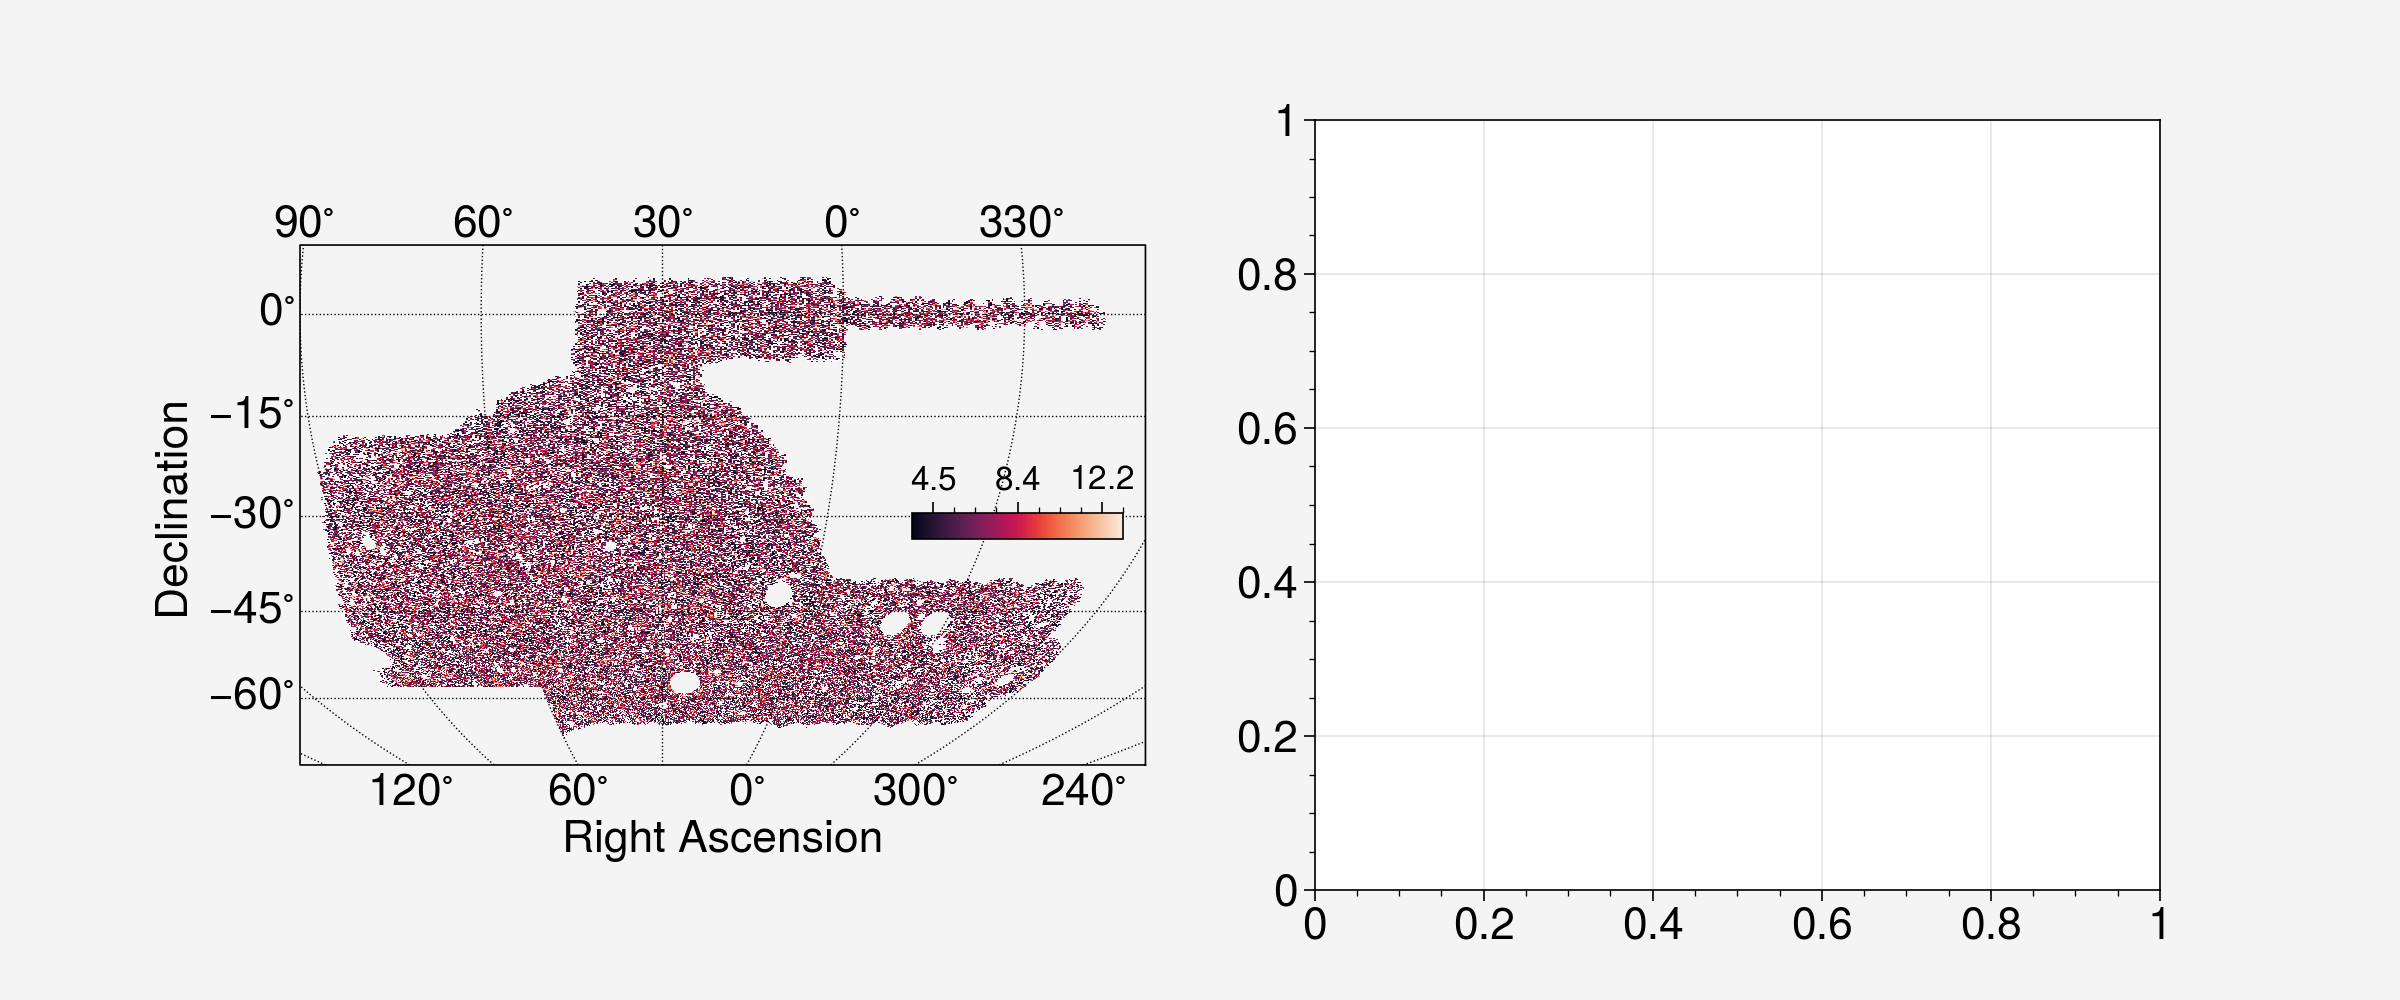

In [5]:
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
my_cmap = matplotlib.cm.get_cmap('rocket')
my_cmap.set_under('white')
m = skyproj.DESSkyproj(ax=ax[0])
m.draw_des(label='DES', edgecolor='none')
_ = m.draw_hspmap(hsp_map_neff_y3, cmap=my_cmap, vmin=3.5, zoom=False)
m.draw_inset_colorbar(fontsize=12)
ax[0].set_title('Y3 weighted number density (H12)', y=1.08)

# Y1

In [40]:
columns = ['ra', 'dec', 'flags_select', 'flags_select_1p', 'flags_select_1m', 'flags_select_2p', 'flags_select_2m', 
           'e1', 'e2', 'e1_1p', 'e1_1m', 'e2_2p', 'e2_2m', 'R11', 'R22']
d = fio.read('/global/cfs/cdirs/des/y1_shape_catalogs/mcal-y1a1-combined-riz-unblind-v4-matched.fits', columns=columns)

In [41]:
len(d['flags_select_1p'])

136930995

In [42]:
# Load ra, dec
mask = (d['flags_select'] == 0)
mask_1p = (d['flags_select_1p'] == 0)
mask_1m = (d['flags_select_1m'] == 0)
mask_2p = (d['flags_select_2p'] == 0)
mask_2m = (d['flags_select_2m'] == 0)
ra = d['ra'][mask]
dec = d['dec'][mask]

# load sheared ellipticities
e1_1m = d['e1_1m'][mask]
e1_1p = d['e1_1p'][mask]
e2_2m = d['e2_2m'][mask]
e2_2p = d['e2_2p'][mask]

# compute responses
dg = 0.01
m1   = (np.average(e1_1p) - np.average(e1_1m)) / (2.*dg)
m2   = (np.average(e2_2p) - np.average(e2_2m)) / (2.*dg)

print ('rg',m1,m2)
del e1_1m, e1_1p, e2_2m, e2_2p

# compute selection responses

# Load ellipticities
e1 = d['e1']
e2 = d['e2']

d_m1   = (np.average(e1[mask_1p]) - np.average(e1[mask_1m])) / (2.*dg)
d_m2   = (np.average(e2[mask_2p]) - np.average(e2[mask_2m])) / (2.*dg)
print ('rg+rs',m1+d_m1,m2+d_m2)
del mask_1m, mask_1p, mask_2m, mask_2p

# you can also simply use the average responses in the catalogs, but they will be slightly less accurate,
# because they are defined as R11 =(e1_1p[mask] -e1_1m[mask]) / (2.*dg), whereas ideally you'd want to
# use the sheared weights as well. The difference is very small, though...
# Load responses
R1 = d['R11']
R2 = d['R22']
R1 = R1[mask]
R2 = R2[mask]

m1_   = np.average(R1)
m2_   = np.average(R2)
print ('rg',m1_,m2_)
del R1, R2

# add responses together
m1   = (m1+d_m1)*np.ones(len(ra))
m2   = (m2+d_m2)*np.ones(len(ra))
s   = (m1+m2)/2. 
w = np.ones(len(s))

e1 = e1[mask]; e2 = e2[mask]
mean_e1 = np.average(e1); mean_e2 = np.average(e2)
sum_ws = np.sum(w * s); sum_w = np.sum(w); sum_w2 = np.sum(w**2)
sigmae2 = 0.5 * (np.sum(w**2 * (e1 - mean_e1)**2)/sum_ws**2 + np.sum(w**2 * (e2 - mean_e2)**2)/sum_ws**2) * (sum_w**2 / sum_w2)
sigma_e = np.sqrt(sigmae2)
print(sigma_e)

rg 0.6406887664077621 0.6424520401731219
rg+rs 0.6519932101687311 0.6535594626888528
rg 0.6406887664077636 0.6424520401731227
0.276668393131085


In [43]:
# neff
desy1_count = make_maps(1, ra, dec, nside_sparse, count=True)
desy1_map_w = make_maps(w, ra, dec, nside_sparse)
desy1_map_w2 = make_maps(w**2, ra, dec, nside_sparse)
neff_y1 = desy1_map_w**2/desy1_map_w2/(hp.pixelfunc.nside2pixarea(nside_sparse,degrees=True)*(60*60))
hsp_map_neff_y1 = hsp.HealSparseMap(nside_coverage=nside_sparse, healpix_map=neff_y1)

# shape noise
sum_we2_2 = make_maps((w*e2)**2, ra, dec, nside_sparse)
sum_we2_1 = make_maps((w*e1)**2, ra, dec, nside_sparse)
sum_w2 = desy1_map_w2
sum_w = desy1_map_w
sum_ws = make_maps((w*s), ra, dec, nside_sparse)
sig_e_y1 = np.sqrt((sum_we2_1/sum_ws**2+sum_we2_2/sum_ws**2)*(sum_w**2/sum_w2)/2.)
hsp_map_sige_y1 = hsp.HealSparseMap(nside_coverage=nside_sparse, healpix_map=sig_e_y1)

# save
dict_maps = dict()
msk = desy1_count!=0.
dict_maps['count'] = desy1_count
dict_maps['Neff'] = desy1_map_w**2/desy1_map_w2
dict_maps['neff'] = neff_y1
dict_maps['sige'] = sig_e_y1
dict_maps['mask'] = msk
with open('/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/y1_maps_4096.pkl', 'wb') as f:
    pickle.dump(dict_maps, f)

<ipython-input-43-8d77972b179f>:5: RuntimeWarning: invalid value encountered in true_divide
  neff_y1 = desy1_map_w**2/desy1_map_w2/(hp.pixelfunc.nside2pixarea(nside_sparse,degrees=True)*(60*60))
<ipython-input-43-8d77972b179f>:14: RuntimeWarning: invalid value encountered in true_divide
  sig_e_y1 = np.sqrt((sum_we2_1/sum_ws**2+sum_we2_2/sum_ws**2)*(sum_w**2/sum_w2)/2.)
<ipython-input-43-8d77972b179f>:21: RuntimeWarning: invalid value encountered in true_divide
  dict_maps['Neff'] = desy1_map_w**2/desy1_map_w2


Text(0.5, 1.08, 'Y1 shape noise (H12)')

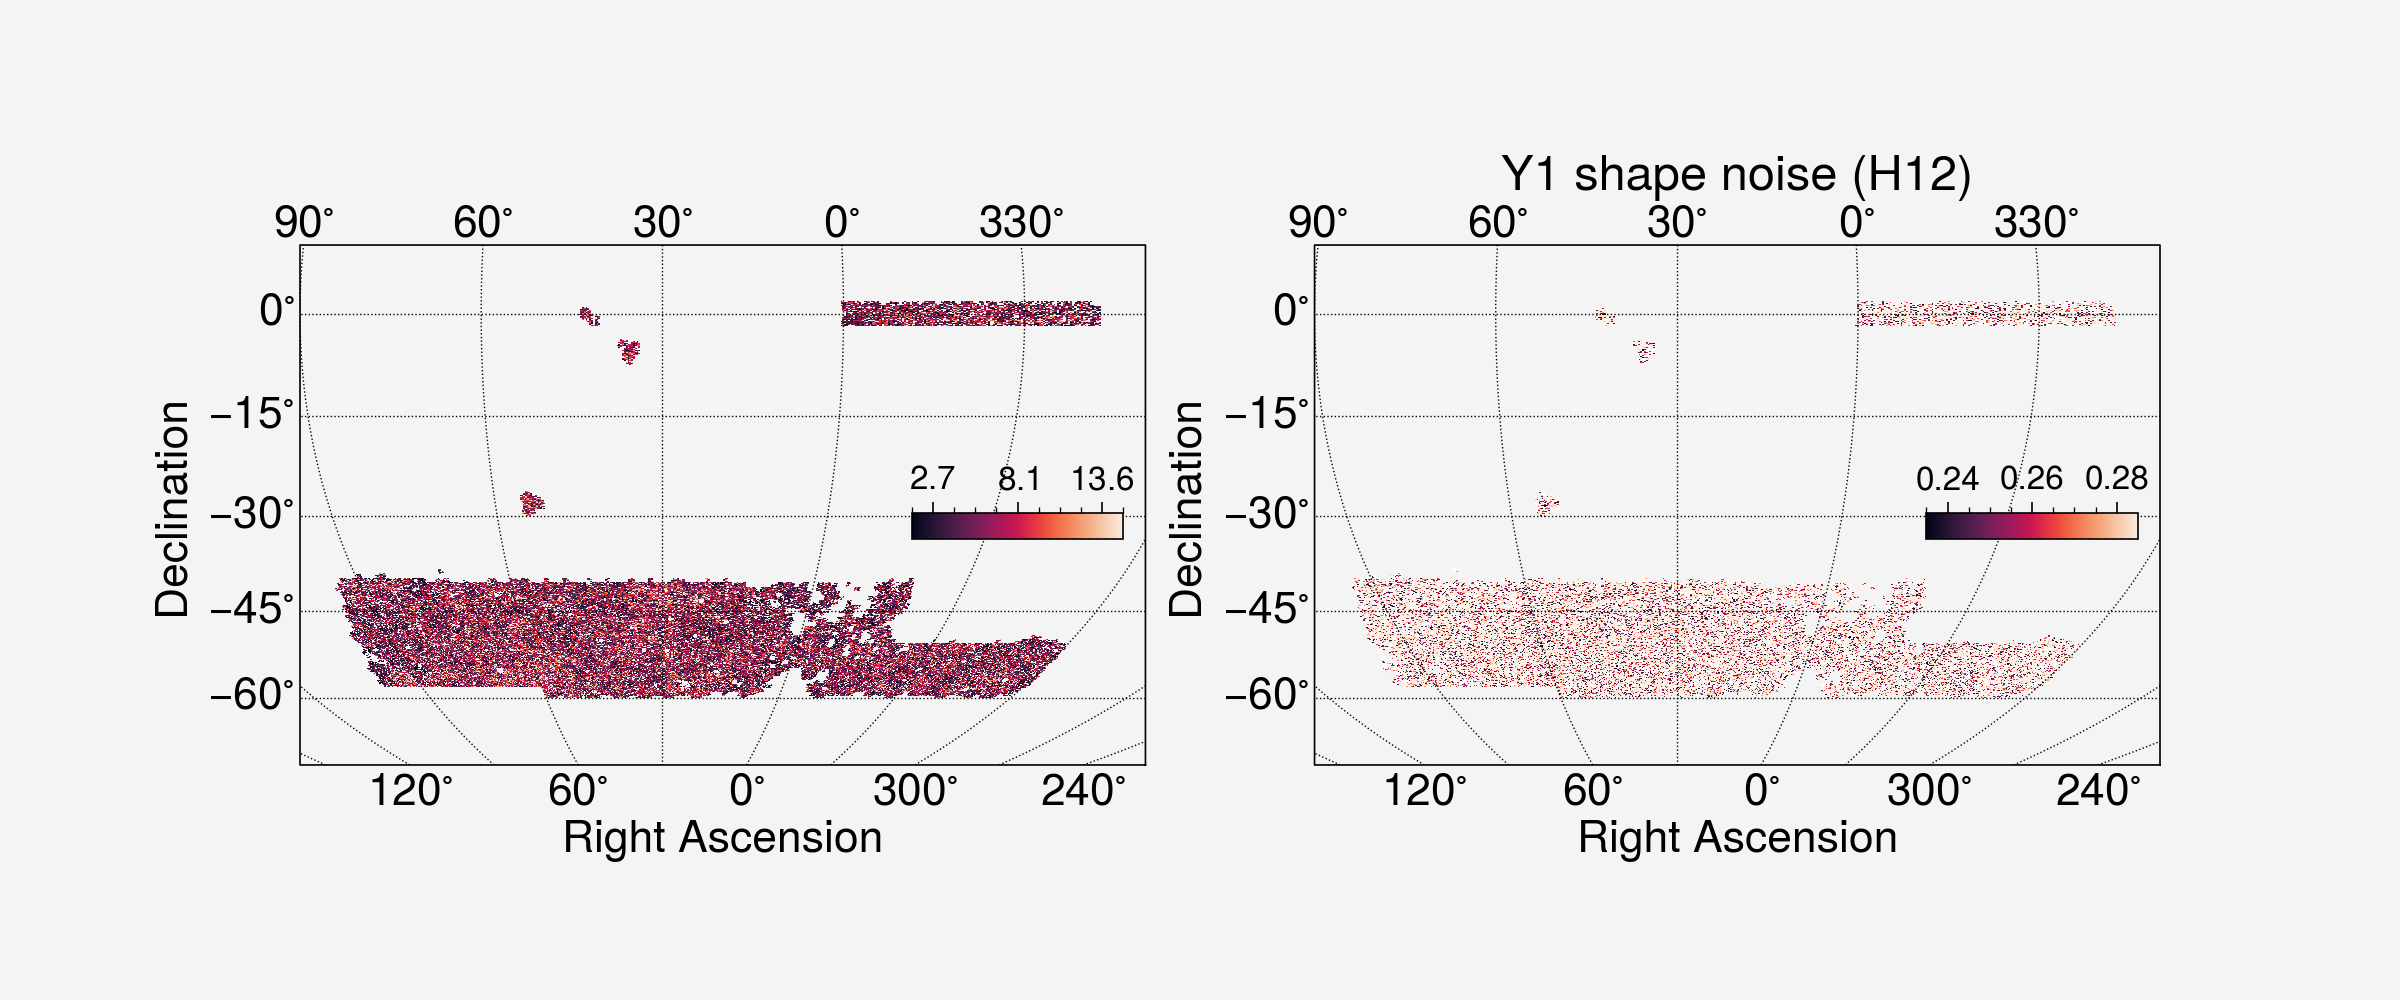

In [44]:
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
my_cmap = matplotlib.cm.get_cmap('rocket')
my_cmap.set_under('white')
m = skyproj.DESSkyproj(ax=ax[0])
m.draw_des(label='DES', edgecolor='none')
_ = m.draw_hspmap(hsp_map_neff_y1, cmap=my_cmap, zoom=False)
m.draw_inset_colorbar(fontsize=12)
ax[0].set_title('Y1 weighted number density (H12)', y=1.08)

m = skyproj.DESSkyproj(ax=ax[1])
m.draw_des(label='DES', edgecolor='none')
_ = m.draw_hspmap(hsp_map_sige_y1, cmap=my_cmap, vmin=0.23, vmax=0.29, zoom=False)
m.draw_inset_colorbar(format='%.2f',fontsize=12)
plt.title('Y1 shape noise (H12)', y=1.08)

# SV

In [5]:
columns = ['E_1', 'E_2', 'W', 'ERROR_FLAG', 'SNR_R', 'T_R', 'MEAN_PSF_T', 'FLUX_I', 'MAG_I', 'T','T_ERR', 'LOG10_SB_I', 'SENS_AVG', 'COADD_OBJECTS_ID']
columns_gold = ['RA', 'DEC', 'MODEST_CLASS', 'BADFLAG', 'FLAGS_G', 'FLAGS_R', 'FLAGS_I', 'FLAGS_Z',
                'CLASS_STAR_I', 'MAG_AUTO_G', 'MAG_AUTO_R', 'MAG_AUTO_I', 'MAG_AUTO_Z', 'SPREAD_MODEL_I', 'SPREADERR_MODEL_I', 'MAG_PSF_I']
d = fio.read('/pscratch/sd/m/myamamot/sva1_gold_r1.0_ngmix.fits', columns=columns)
d_gold = fio.read('/pscratch/sd/m/myamamot/sva1_gold_r1.0_catalog.fits', columns=columns_gold)
d_ = fio.read('/pscratch/sd/m/myamamot/sva1_gold_r1.0_wlinfo.fits', columns=['RA', 'DEC', 'SVA1_FLAG', 'NGMIX_FLAG', 'COADD_OBJECTS_ID'])

In [15]:
# Load ra, dec
# bright_test = ((d_gold['CLASS_STAR_I'] > 0.3) & (d_gold['MAG_AUTO_I'] < 18.0))
# locus_test = (d_gold['SPREAD_MODEL_I'] + 3*d_gold['SPREADERR_MODEL_I'] < 0.003)
# faint_psf_test = ((d_gold['MAG_PSF_I'] > 30.0) & (d_gold['MAG_AUTO_I'] < 21.0))
# crazy_color = (((d_gold['MAG_AUTO_G'] - d_gold['MAG_AUTO_R']) < -1) | ((d_gold['MAG_AUTO_G'] - d_gold['MAG_AUTO_R']) > 4) | 
#                ((d_gold['MAG_AUTO_I'] - d_gold['MAG_AUTO_Z']) < -1) | ((d_gold['MAG_AUTO_I'] - d_gold['MAG_AUTO_Z']) > 4))
# mask = ((d['ERROR_FLAG'] == 0) & (d_gold['MODEST_CLASS'] == 1) & (d_gold['BADFLAG'] == 0) & (d_gold['FLAGS_G'] == 0) & (d_gold['FLAGS_R'] == 0) & 
#         (d_gold['FLAGS_I'] == 0) & (d_gold['FLAGS_Z'] == 0) & ~crazy_color & (d['SNR_R'] > 15) & (d['T_R']/d['MEAN_PSF_T'] > 0.15) &
#         (d['MAG_I'] + 3.5*np.log10(d['FLUX_I']/d['T']) >= 28) & (d['T'] + d['T_ERR'] >= 0.02) & ~bright_test & ~locus_test & ~faint_psf_test)
mask = ((d_['SVA1_FLAG'] == 0) & (d_['NGMIX_FLAG'] == 0))
ngmask = np.in1d(d['COADD_OBJECTS_ID'], d_['COADD_OBJECTS_ID'][mask])
ra = d_gold['RA'][ngmask]
dec = d_gold['DEC'][ngmask]

# Load ellipticities
e1 = d['E_1'][ngmask]
print(len(ra), len(e1))
e2 = d['E_2'][ngmask]
w = d['W'][ngmask]
s = d['SENS_AVG'][ngmask]

mean_e1 = np.average(e1, weights=w); mean_e2 = np.average(e2, weights=w)
sum_ws = np.sum(w * s); sum_w = np.sum(w); sum_w2 = np.sum(w**2)
sigmae2 = 0.5 * (np.sum(w**2 * (e1 - mean_e1)**2)/sum_ws**2 + np.sum(w**2 * (e2 - mean_e2)**2)/sum_ws**2) * (sum_w**2 / sum_w2)
sigma_e = np.sqrt(sigmae2)
neff = (sum_w**2/sum_w2)/139/60**2
print(sigma_e, neff)

3446533 3446533
0.2779860470230244 6.760638734184698


In [1]:

from astropy.io import fits as pyfits
import numpy

ngcat = pyfits.open('/pscratch/sd/m/myamamot/sva1_gold_r1.0_ngmix.fits')[1].data
fcat = pyfits.open('/pscratch/sd/m/myamamot/sva1_gold_r1.0_wlinfo.fits')[1].data

sva1 = fcat['SVA1_FLAG'] == 0
ngmix = fcat['NGMIX_FLAG'] == 0

all_ng = sva1 & ngmix
ngmask = numpy.in1d(ngcat['COADD_OBJECTS_ID'], fcat['COADD_OBJECTS_ID'][all_ng])

ngcat = ngcat[ngmask]

nge1 = ngcat['E_1']
nge2 = ngcat['E_2']
ngvare = (ngcat['E_COV_1_1'] + ngcat['E_COV_2_2'])
ngw = ngcat['W']
ngs = ngcat['SENS_AVG']

sigsn_ng = numpy.sqrt(numpy.sum( (ngw**2 * (nge1**2 + nge2**2 - ngvare)) ) /
                      (2. * numpy.sum( (ngw**2 * ngs**2) )))

print('ngmix has sigma_SN = ',sigsn_ng)

ntot_ng = ((sigsn_ng**2 * numpy.sum(ngw * ngs)**2) /
           numpy.sum(ngw**2 * (ngs**2 * sigsn_ng**2 + ngvare/2.)))
neff_ng = ntot_ng / 139 / 60**2

print('ntot = ',ntot_ng,' neff = ',neff_ng)
nalt_ng = numpy.sum(ngw*ngs)**2 / numpy.sum(ngw**2 * ngs**2) * (1. -
            numpy.sum(ngw**2*ngvare/2.) / numpy.sum(ngw**2*(nge1**2+nge2**2)/2.))
print('alt = ',nalt_ng,' neff = ',nalt_ng / 139 / 60**2)


print('mean shape = ',numpy.sum( (ngw * (nge1 + 1j*nge2)) ) / numpy.sum( ngw * ngs ))
print('sigma = ',numpy.sqrt(numpy.sum( (ngw**2 * (nge1**2 + nge2**2)) ) / numpy.sum( ngw * ngs )**2))


print('CFHT definition:')
ntot_ng = numpy.sum(ngw)**2 / numpy.sum(ngw**2)
neff_ng = ntot_ng / 139 / 60**2
print('ngmix: ',ntot_ng, neff_ng)
sige_ng = numpy.sqrt(ntot_ng * numpy.sum(ngw**2*(nge1**2+nge2**2)/2)/numpy.sum(ngw*ngs)**2)
print('ngmix sige = ',sige_ng)


ngmix has sigma_SN =  0.256444764298218
ntot =  2879003.637588542  neff =  5.753404551535855
alt =  2879003.6375885406  neff =  5.753404551535852
mean shape =  (-4.277444611606212e-05+0.0010742312219925428j)
sigma =  0.00021374094626709156
CFHT definition:
ngmix:  3383023.6225860226 6.760638734184698
ngmix sige =  0.2779874854327141


In [37]:
# neff
dessv_count = make_maps(1, ra, dec, nside_sparse, count=True)
dessv_map_w = make_maps(w, ra, dec, nside_sparse)
dessv_map_w2 = make_maps(w**2, ra, dec, nside_sparse)
neff_sv = dessv_map_w**2/dessv_map_w2/(hp.pixelfunc.nside2pixarea(nside_sparse,degrees=True)*(60*60))
hsp_map_neff_sv = hsp.HealSparseMap(nside_coverage=nside_sparse, healpix_map=neff_sv)

# shape noise
sum_we2_2 = make_maps((w*e2)**2, ra, dec, nside_sparse)
sum_we2_1 = make_maps((w*e1)**2, ra, dec, nside_sparse)
sum_w2 = dessv_map_w2
sum_w = dessv_map_w
sum_ws = make_maps((w*s), ra, dec, nside_sparse)
sig_e_sv = np.sqrt((sum_we2_1/sum_ws**2+sum_we2_2/sum_ws**2)*(sum_w**2/sum_w2)/2.)
hsp_map_sige_sv = hsp.HealSparseMap(nside_coverage=nside_sparse, healpix_map=sig_e_sv)

# save
dict_maps = dict()
msk = dessv_count!=0.
dict_maps['count'] = dessv_count
dict_maps['Neff'] = dessv_map_w**2/dessv_map_w2
dict_maps['neff'] = neff_sv
dict_maps['sige'] = sig_e_sv
dict_maps['mask'] = msk
with open('/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/sv_maps_4096.pkl', 'wb') as f:
    pickle.dump(dict_maps, f)

<ipython-input-37-bc24fbc6b715>:6: RuntimeWarning: invalid value encountered in true_divide
  neff_sv = dessv_map_w**2/dessv_map_w2/(hp.pixelfunc.nside2pixarea(nside_sparse,degrees=True)*(60*60))
<ipython-input-37-bc24fbc6b715>:15: RuntimeWarning: invalid value encountered in true_divide
  sig_e_sv = np.sqrt((sum_we2_1/sum_ws**2+sum_we2_2/sum_ws**2)*(sum_w**2/sum_w2)/2.)
<ipython-input-37-bc24fbc6b715>:22: RuntimeWarning: invalid value encountered in true_divide
  dict_maps['Neff'] = dessv_map_w**2/dessv_map_w2


Text(0.5, 1.08, 'SV shape noise (H12)')

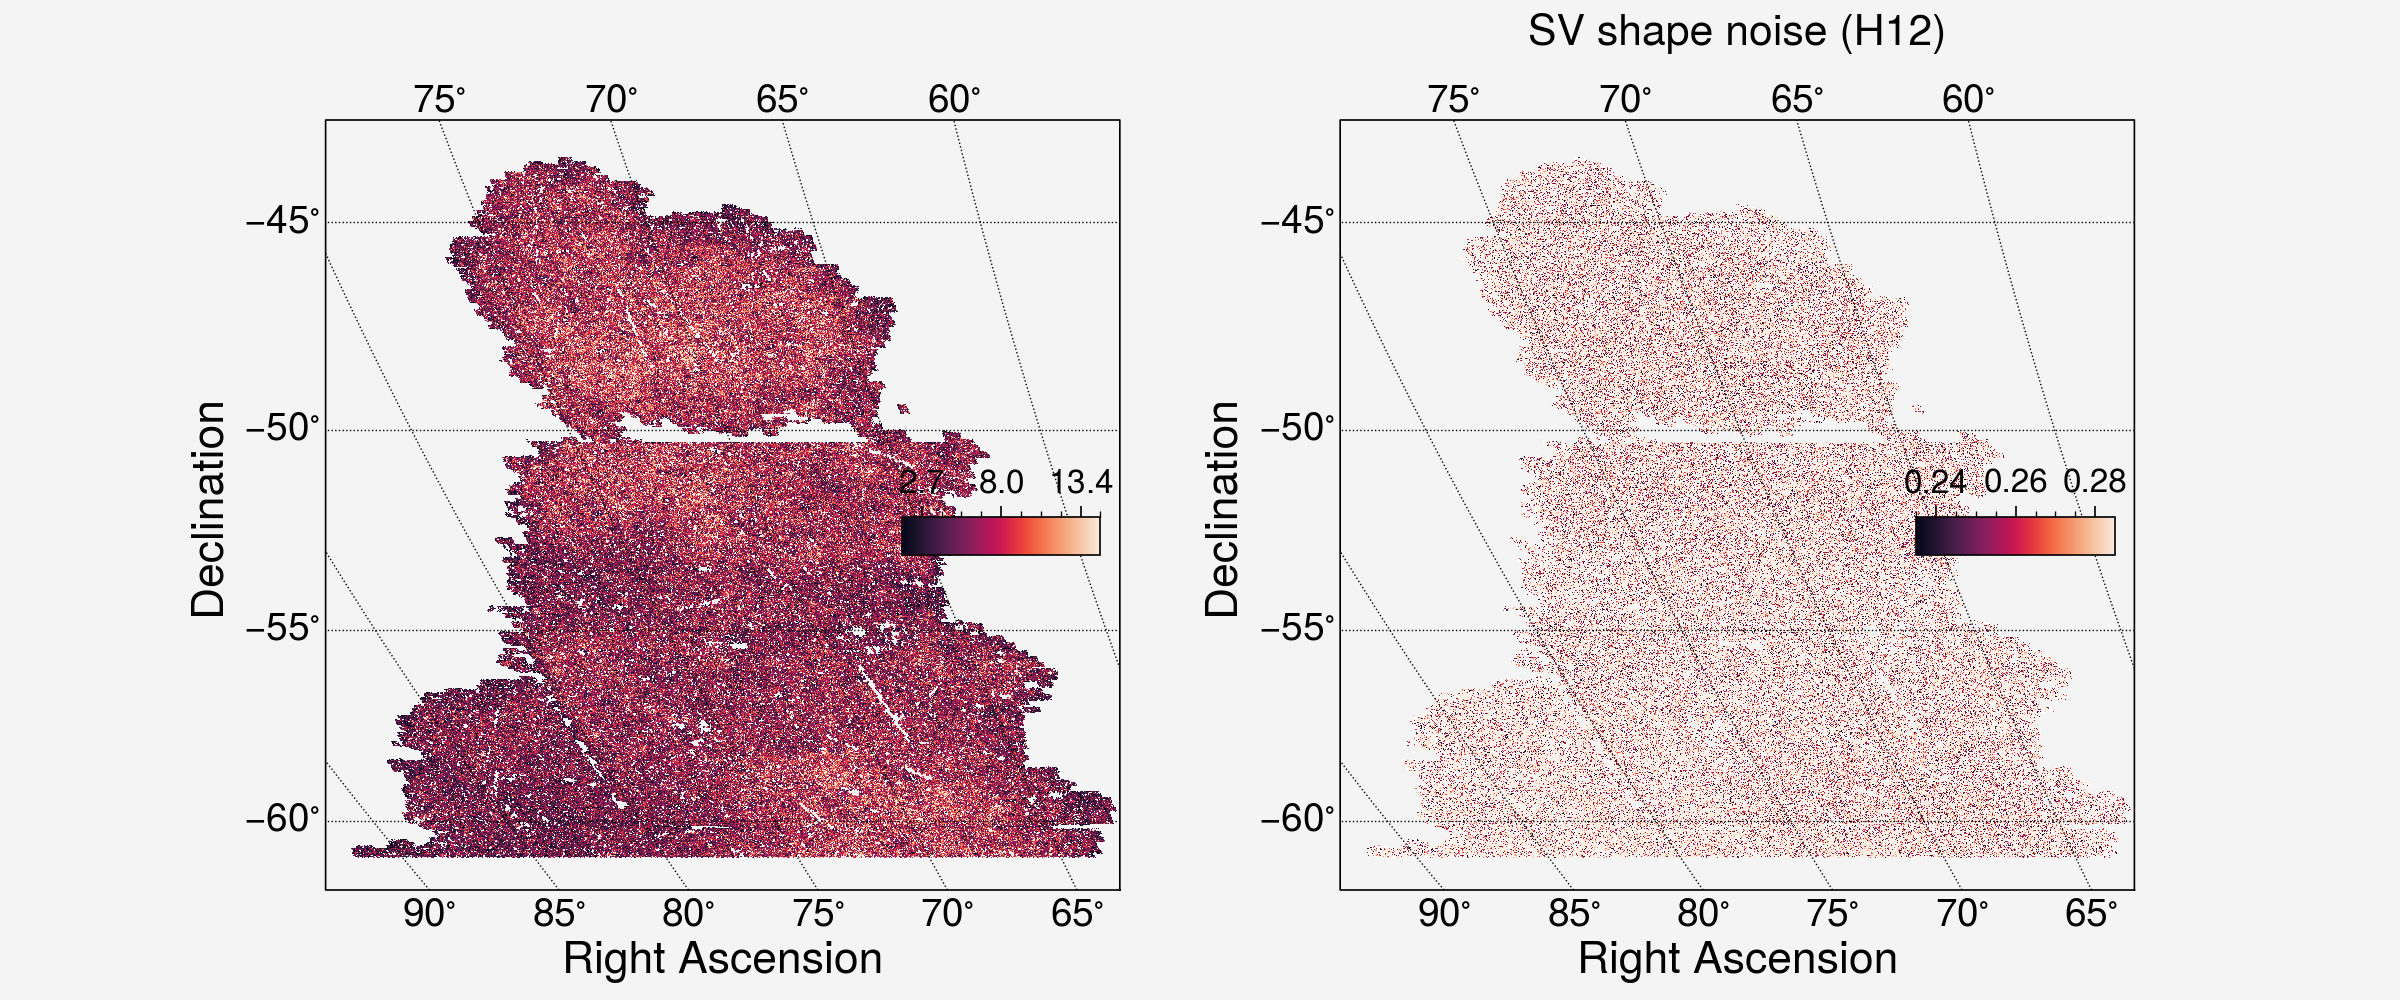

In [38]:
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
my_cmap = matplotlib.cm.get_cmap('rocket')
my_cmap.set_under('white')
m = skyproj.DESSkyproj(ax=ax[0])
m.draw_des(label='DES', edgecolor='none')
_ = m.draw_hspmap(hsp_map_neff_sv, cmap=my_cmap, zoom=True)
m.draw_inset_colorbar(fontsize=12)
ax[0].set_title('SV weighted number density (H12)', y=1.08)

m = skyproj.DESSkyproj(ax=ax[1])
m.draw_des(label='DES', edgecolor='none')
_ = m.draw_hspmap(hsp_map_sige_sv, cmap=my_cmap, vmin=0.23, vmax=0.29, zoom=True)
m.draw_inset_colorbar(format='%.2f',fontsize=12)
plt.title('SV shape noise (H12)', y=1.08)

# neff maps gif

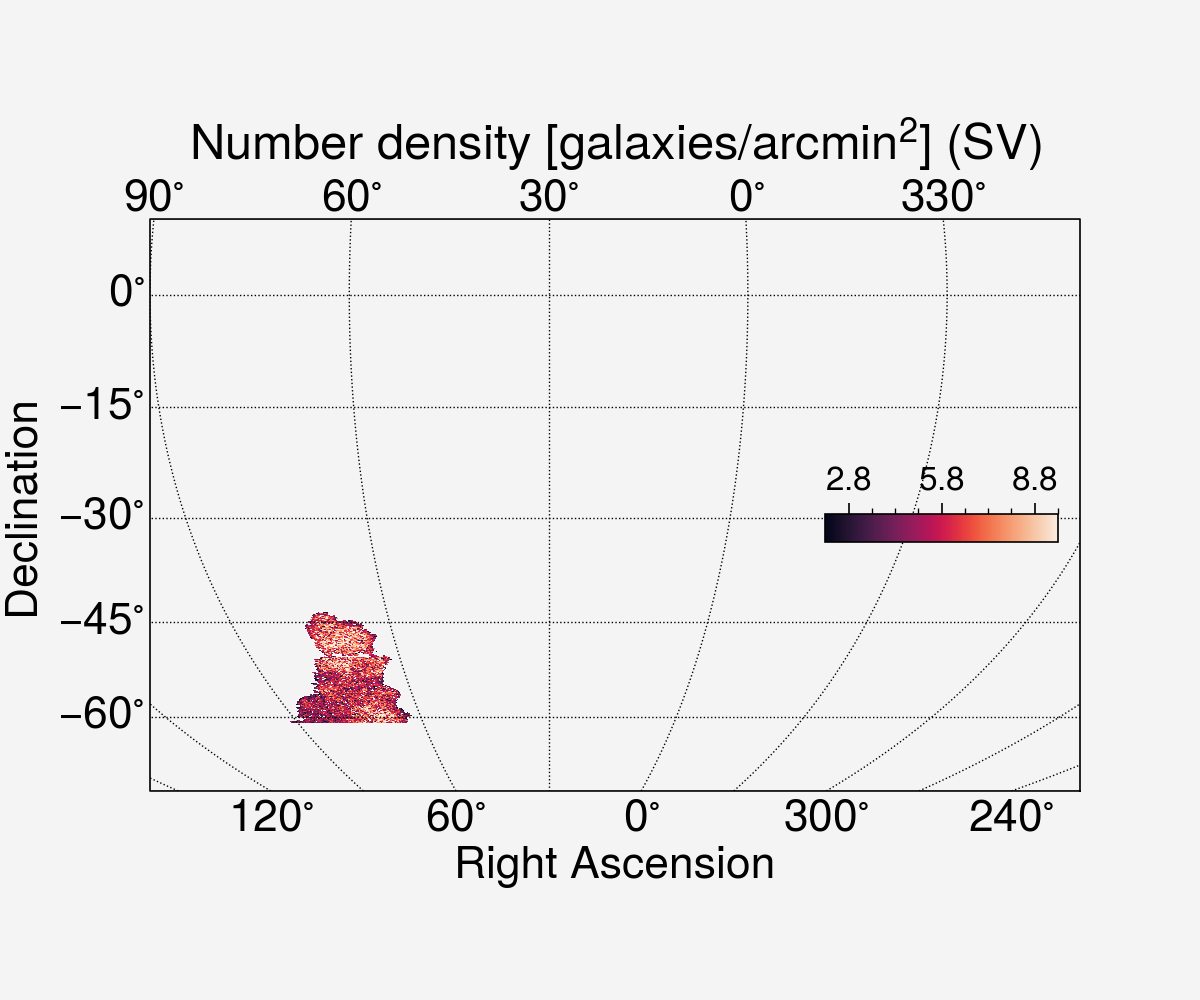

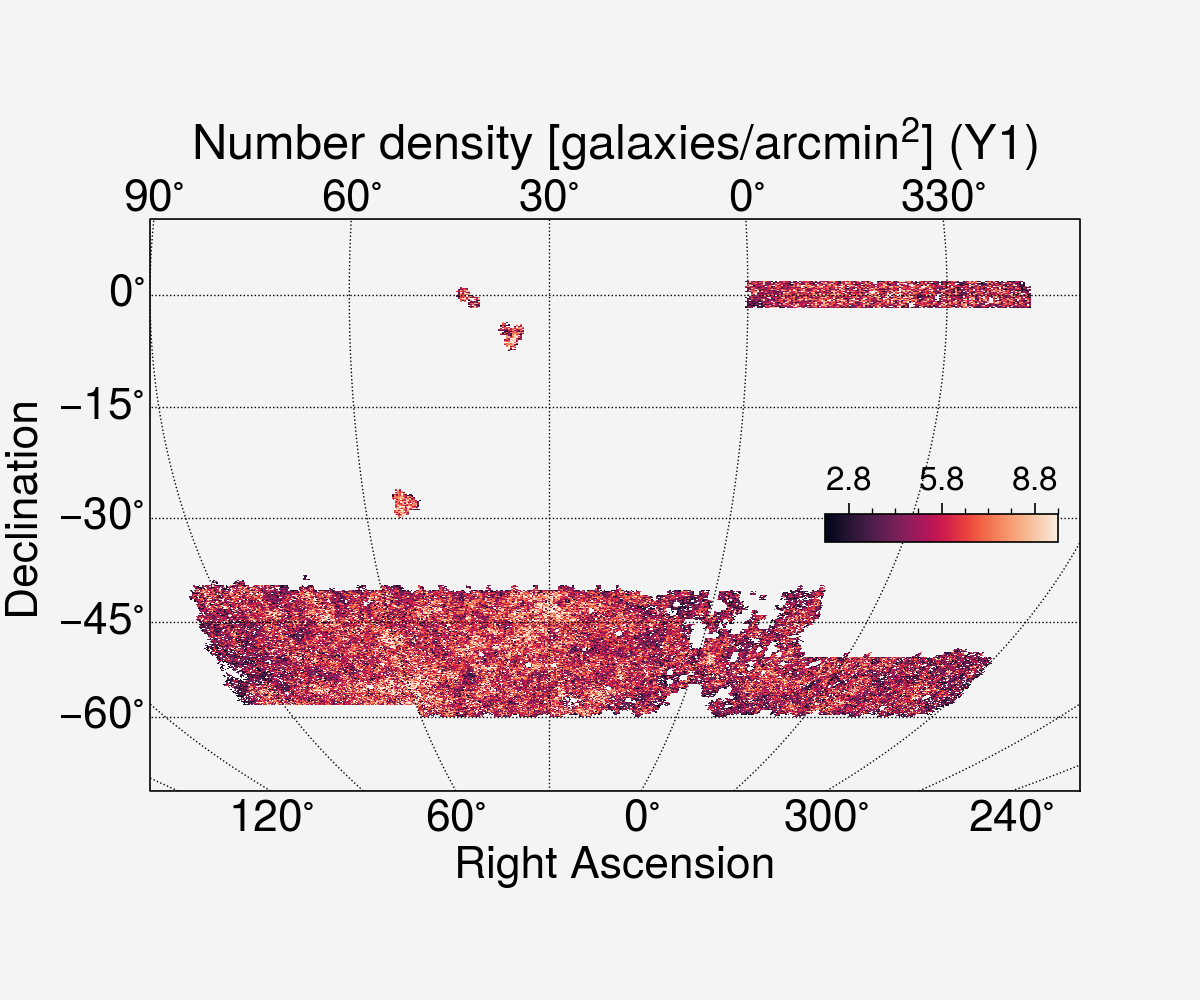

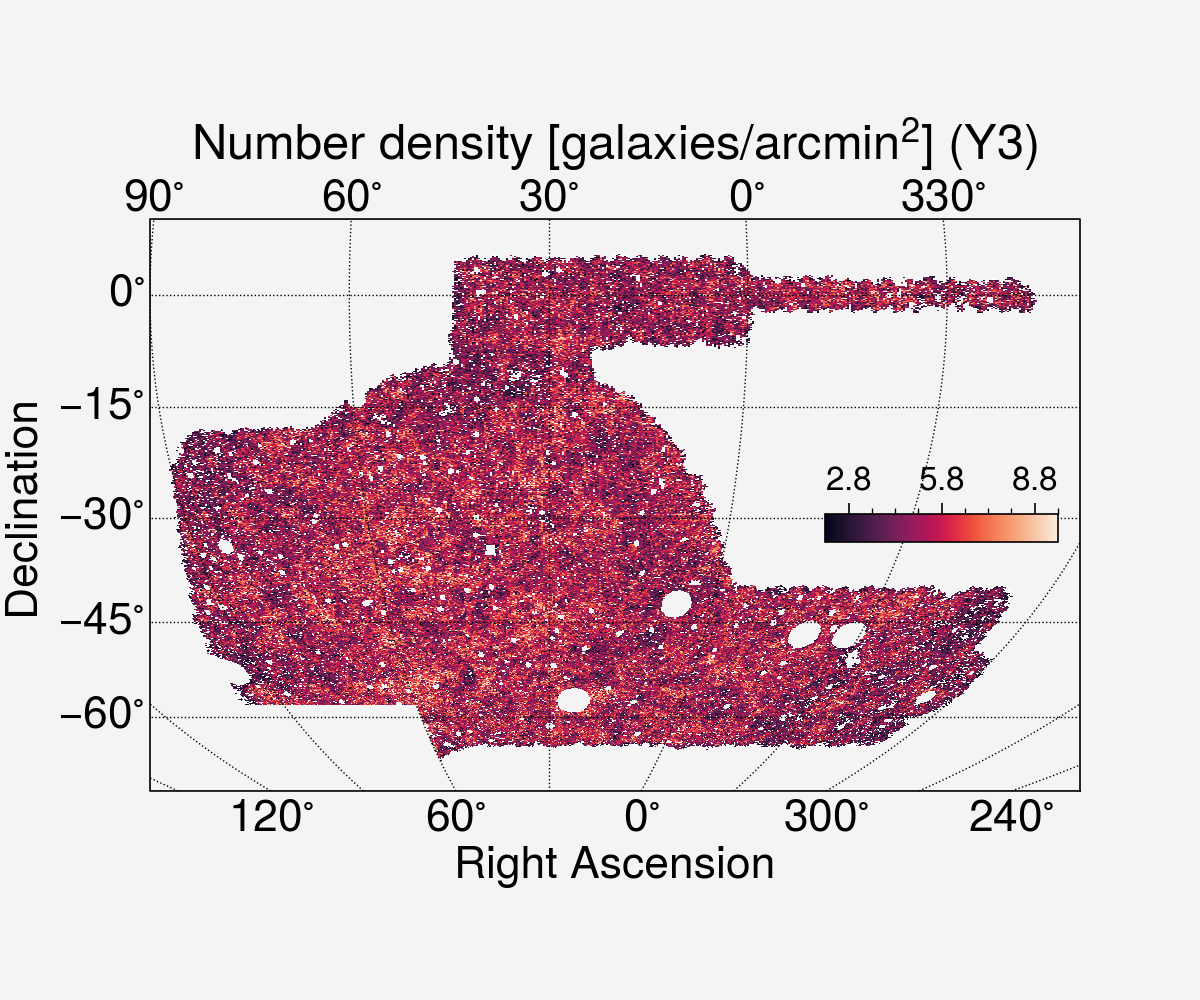

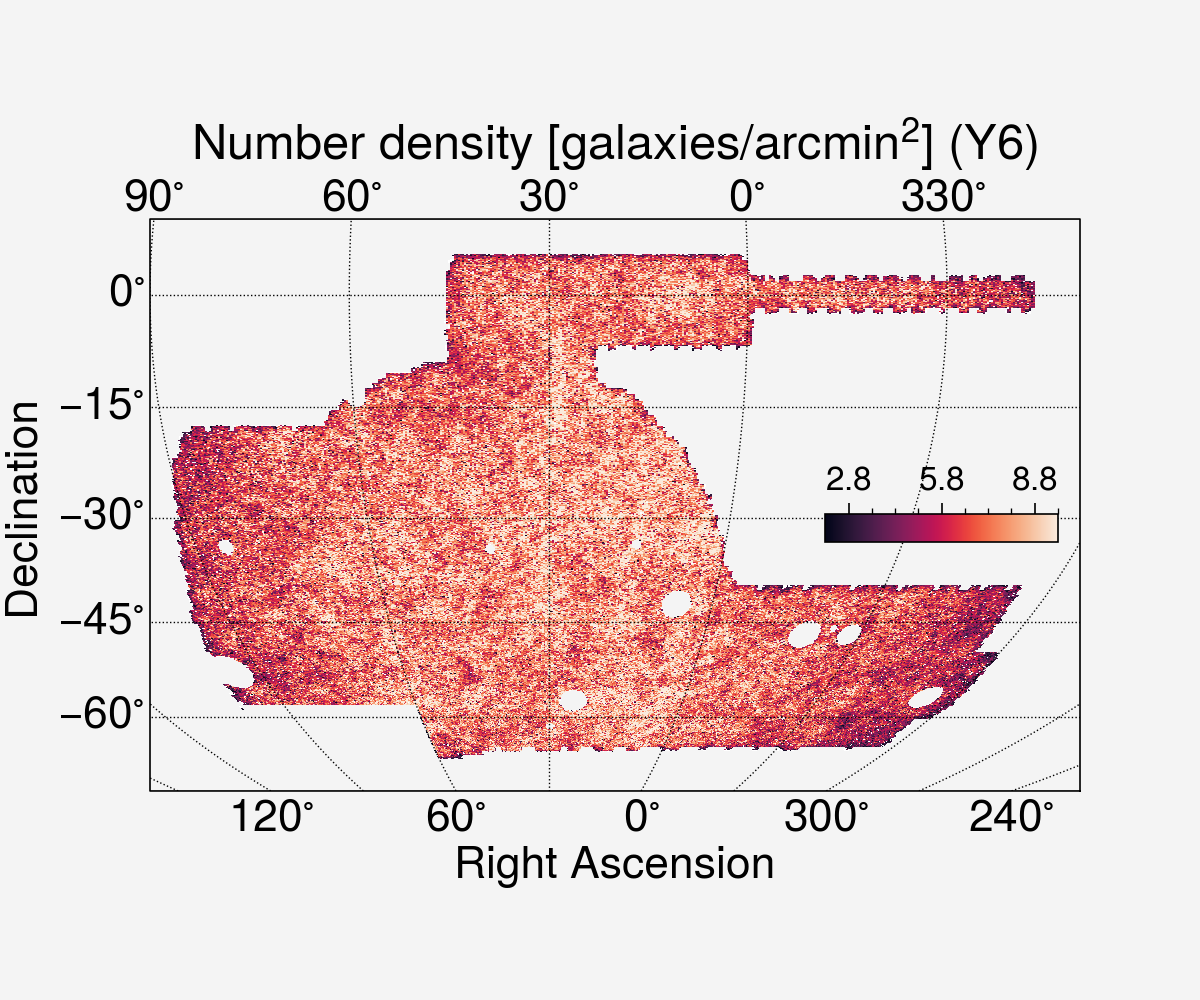

In [20]:
ys = ['SV', 'Y1', 'Y3', 'Y6']
matplotlib.rcParams.update({'font.size': 16})
for i,f in enumerate(['sv', 'y1', 'y3', 'y6']):
    with open('/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v6_UNBLINDED/'+f+'_maps.pkl', 'rb') as n:
        d = pickle.load(n)

    hsp_map_neff = hsp.HealSparseMap(nside_coverage=nside_sparse, healpix_map=d['neff'])
    fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))
    my_cmap = matplotlib.cm.get_cmap('rocket')
    my_cmap.set_under('white')
    m = skyproj.DESSkyproj(ax=ax)
    m.draw_des(label='DES', edgecolor='none')
    _ = m.draw_hspmap(hsp_map_neff, cmap=my_cmap, vmin=2.0, vmax=9.5, zoom=False)
    m.draw_inset_colorbar(fontsize=12)
    plt.title(r'Number density [galaxies/arcmin$^2$] (%s)'%ys[i], y=1.08)
    plt.savefig('/global/homes/m/myamamot/DES/des-y6-analysis/vf_figures/v6_UNBLINDED/%s_maps4gif.png'%f)